# Segmentación de Carreteras con Machine Learning

Este notebook implementa un sistema de aprendizaje automático para detectar carreteras en imágenes satelitales.

**Objetivo**: Comparar Random Forest, SVM y KNN con/sin PCA para segmentación de carreteras.

**Pipeline**:
1. Carga de datos y extracción de características
2. Reducción de dimensionalidad (PCA)
3. Entrenamiento de modelos
4. Evaluación y comparación de resultados

## 0. Imports y Configuración Inicial

In [19]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, feature, morphology, exposure
from skimage.util import img_as_ubyte
from sklearn.metrics import jaccard_score, accuracy_score, f1_score

## 1. Funciones de Extracción de Características

Aplicamos múltiples filtros para obtener 13 características por píxel:
- Canales RGB suavizados
- HSV Saturación
- Lab (a, b)
- Sobel (bordes)
- DoG (Difference of Gaussians)
- Frangi (estructuras tubulares)
- Hessiana (curvatura)
- Entropía y gradiente morfológico

In [20]:
def normalizar_car(array):
    min_val = np.min(array)
    max_val = np.max(array)
    if max_val - min_val == 0: return array
    return (array - min_val) / (max_val - min_val)

def extraer_caracteristicas_pixel(image_rgb):
    caracteristicas = []
    # Preprocesado

    #equalize_adapthist implementa el algoritmo CLAHE: Mejora el contraste de forma local.
    #A diferencia de una ecualización global,
    #esta evita saturar áreas brillantes y ayuda a resaltar detalles en sombras.
    img_eq = exposure.equalize_adapthist(image_rgb, clip_limit=0.03)

    # Filtro gausiano. Aplica un desenfoque para reducir el ruido de alta frecuencia,
    # asegurando que los filtros posteriores
    # no interpreten ruido aleatorio como información relevante.
    img_smooth = filters.gaussian(img_eq, sigma=1, channel_axis=-1)


    gray = color.rgb2gray(img_smooth)

    #HSV Saturación. separar objetos por la pureza de su color,
    hsv = color.rgb2hsv(img_smooth)
    #Lab (a, b) El espacio Lab separa la luminosidad L de los componentes de color a y b.
    lab = color.rgb2lab(img_smooth)

    # recolectamos las características
    caracteristicas.append(img_smooth[:,:,0])
    caracteristicas.append(img_smooth[:,:,1])
    caracteristicas.append(img_smooth[:,:,2])
    caracteristicas.append(hsv[:,:,1])
    caracteristicas.append(normalizar_car(lab[:,:,1]))
    caracteristicas.append(normalizar_car(lab[:,:,2]))

    #Filtro Sobel. Calcula el gradiente de intensidad.
    #Resalta los bordes verticales y horizontales.
    #Sirve para encontrar siluetas
    edge_sobel = filters.sobel(gray)
    caracteristicas.append(normalizar_car(edge_sobel))

    # DoG (Difference of Gaussians)
    # Se obtiene restando una versión muy desenfocada de la imagen de una menos desenfocada.
    # Actúa como un filtro de paso de banda que resalta detalles y bordes
    dog = filters.gaussian(gray, sigma=1) - filters.gaussian(gray, sigma=8)
    caracteristicas.append(normalizar_car(dog))

    # Filtro Frangi
    # Este filtro está diseñado específicamente para detectar estructuras tubulares
    # o filamentosas (como vasos sanguíneos, carreteras o fibras).
    # Utiliza los autovalores de la matriz Hessiana para determinar como de parecido a un tubo es un píxel.
    frangi = filters.frangi(gray, sigmas=range(1, 4), black_ridges=False)
    caracteristicas.append(normalizar_car(frangi))

    # Matriz Hessiana
    # Se calcula a dos escalas (1.5 y 3.5). La matriz Hessiana mide la curvatura local de la intensidad de la imagen.
    # Los autovalores (eigenvalues) resultantes te dicen si estás en una zona plana, en una cresta (borde) o en un rincón.
    # Al extraer eigvals[0], estás capturando la curvatura principal de la superficie de la imagen.

    for escala in [1.5, 3.5]:
        H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')
        eigvals = feature.hessian_matrix_eigvals(H_elems)
        caracteristicas.append(normalizar_car(eigvals[0]))

    gray_ubyte = img_as_ubyte(gray)
    #mide el desorden o complejidad de las texturas de las que el pixel forma parte
    entropy = filters.rank.entropy(gray_ubyte, morphology.disk(3))
    caracteristicas.append(normalizar_car(entropy))

    #Este filtro resalta los limites de los objetos
    morph_grad = filters.rank.gradient(gray_ubyte, morphology.disk(2))
    caracteristicas.append(normalizar_car(morph_grad))

    return np.stack(caracteristicas, axis=-1)

## 2. Carga de Datos y Visualización Inicial

Cargamos las imágenes satelitales y sus etiquetas ground truth desde la carpeta local `roads/`

SAT: ['roads\\sat\\10078675_15.tiff', 'roads\\sat\\10228675_15.tiff', 'roads\\sat\\10228705_15.tiff']
GT: ['roads\\gt\\10078675_15.tif', 'roads\\gt\\10228675_15.tif', 'roads\\gt\\10228705_15.tif']


C:\Users\enrique.jimenezmarti\AppData\Local\Temp\ipykernel_10412\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


Shape de la matriz de caracteristicas extraidas:(1500, 1500, 13)


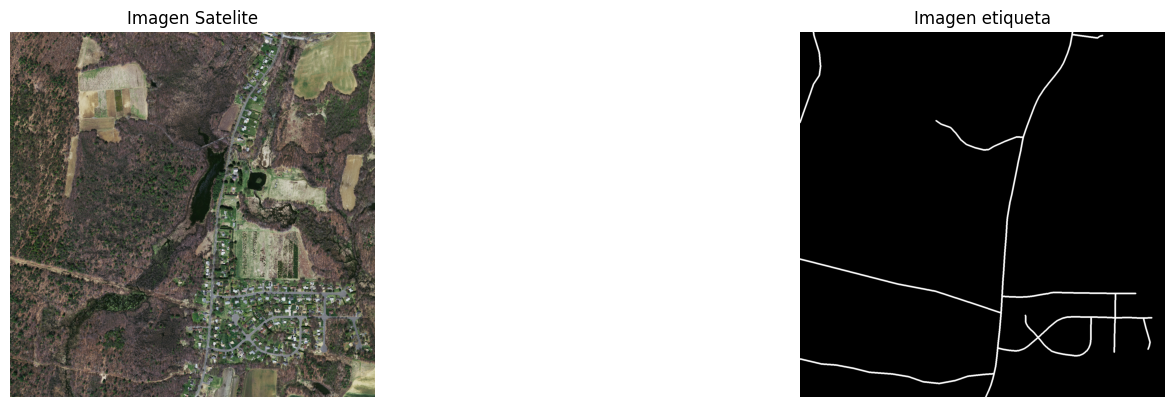

In [21]:
# Usa datos locales en 'roads' en esta carpeta
DIRBASE = os.path.join("roads")

fotos_satelite = glob.glob(os.path.join(DIRBASE, "sat", "*.tiff"))
fotos_gt = glob.glob(os.path.join(DIRBASE, "gt", "*.tif"))

fotos_satelite.sort()
fotos_gt.sort()

print("SAT:", fotos_satelite[:3])
print("GT:", fotos_gt[:3])

if len(fotos_satelite) == 0 or len(fotos_gt) == 0:
    raise FileNotFoundError(f"No se encontraron imágenes en {os.path.abspath(DIRBASE)}")

img_sat = io.imread(fotos_satelite[0])
img_gt = io.imread(fotos_gt[0], as_gray=True)

sat_car = extraer_caracteristicas_pixel(img_sat)
print(f"Shape de la matriz de caracteristicas extraidas:{sat_car.shape}")

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(img_sat); plt.title("Imagen Satelite"); plt.axis("off")
plt.subplot(133)
plt.imshow(img_gt, cmap='gray'); plt.title("Imagen etiqueta"); plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Preparación del Dataset

Vamos a cargar múltiples imágenes y preparar los datos para entrenar los modelos:
- **X**: Matriz de características (n_píxeles × 13)
- **y**: Vector de etiquetas binarias (0=no carretera, 1=carretera)

In [ ]:
def preparar_datos(lista_sat, lista_gt, max_imagenes=None):
    """
    Carga múltiples imágenes y extrae características
    
    Args:
        lista_sat: Lista de rutas a imágenes satelitales
        lista_gt: Lista de rutas a ground truth
        max_imagenes: Número máximo de imágenes a procesar (None = todas)
    
    Returns:
        X: Matriz de características (n_píxeles, 13)
        y: Vector de etiquetas (n_píxeles,)
    """
    X_list = []
    y_list = []
    
    if max_imagenes is not None:
        lista_sat = lista_sat[:max_imagenes]
        lista_gt = lista_gt[:max_imagenes]
    
    for i, (path_sat, path_gt) in enumerate(zip(lista_sat, lista_gt)):
        print(f"Procesando imagen {i+1}/{len(lista_sat)}...", end="\r")
        
        # Cargar imágenes
        img_sat = io.imread(path_sat)
        img_gt = io.imread(path_gt, as_gray=True)
        
        # Extraer características (H × W × 13)
        features = extraer_caracteristicas_pixel(img_sat)
        
        # Aplanar a (H*W, 13)
        H, W, C = features.shape
        X_img = features.reshape(-1, C)
        
        # Preparar etiquetas: binarizar (>0.5 = carretera)
        y_img = (img_gt.ravel() > 0.5).astype(int)
        
        X_list.append(X_img)
        y_list.append(y_img)
    
    print(f"\nProcesadas {len(lista_sat)} imágenes correctamente")
    
    # Concatenar todas las imágenes
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    
    return X, y

In [23]:
# Cargar primeras imágenes para entrenamiento y prueba
# Usar 80% para train, 20% para test

n_total = len(fotos_satelite)
n_train = int(0.8 * n_total)

print(f"Total de imágenes: {n_total}")
print(f"Train: {n_train} | Test: {n_total - n_train}")

# Preparar datos de entrenamiento (primeras 5 imágenes para empezar rápido)
# Puedes aumentar a n_train después
print("\n--- Preparando datos de entrenamiento ---")
X_train, y_train = preparar_datos(fotos_satelite[:5], fotos_gt[:5])

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Proporción carretera/no-carretera: {y_train.mean():.3f}")

Total de imágenes: 20
Train: 16 | Test: 4

--- Preparando datos de entrenamiento ---


C:\Users\enrique.jimenezmarti\AppData\Local\Temp\ipykernel_10412\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


C:\Users\enrique.jimenezmarti\AppData\Local\Temp\ipykernel_10412\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


C:\Users\enrique.jimenezmarti\AppData\Local\Temp\ipykernel_10412\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


C:\Users\enrique.jimenezmarti\AppData\Local\Temp\ipykernel_10412\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


C:\Users\enrique.jimenezmarti\AppData\Local\Temp\ipykernel_10412\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')



Procesadas 5 imágenes correctamente

X_train shape: (11250000, 13)
y_train shape: (11250000,)
Proporción carretera/no-carretera: 0.029


## 4. Reducción de Dimensionalidad con PCA

Reducimos de 13 características a un número menor para:
- Acelerar el entrenamiento
- Reducir ruido
- Comparar rendimiento vs sin reducción

Dimensiones originales: 13
Dimensiones después de PCA: 8
Varianza explicada acumulada: 0.971


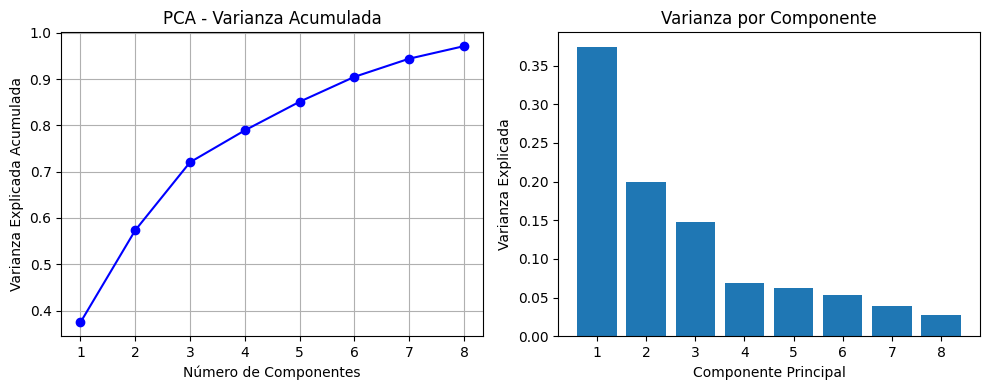

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Estandarizar datos (importante para PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar PCA manteniendo 95% de la varianza
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

print(f"Dimensiones originales: {X_train.shape[1]}")
print(f"Dimensiones después de PCA: {X_train_pca.shape[1]}")
print(f"Varianza explicada acumulada: {pca.explained_variance_ratio_.sum():.3f}")

# Visualizar varianza explicada
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('PCA - Varianza Acumulada')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_)
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza por Componente')
plt.tight_layout()
plt.show()

## 5. Entrenamiento de Modelos

Entrenaremos 3 clasificadores diferentes y compararemos sus resultados

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
import time

# Diccionario para almacenar resultados
resultados = {}

### 5.1 Random Forest

In [26]:
print("=" * 50)
print("Entrenando Random Forest...")
print("=" * 50)

# Submuestrear datos para acelerar (opcional)
# Puedes comentar estas líneas para usar todos los datos
if len(X_train) > 500000:
    indices = resample(range(len(X_train)), n_samples=500000, random_state=42)
    X_train_sample = X_train[indices]
    y_train_sample = y_train[indices]
    X_train_pca_sample = X_train_pca[indices]
else:
    X_train_sample = X_train
    y_train_sample = y_train
    X_train_pca_sample = X_train_pca

# Sin PCA
print("\n1. Random Forest SIN PCA:")
t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, 
                                   random_state=42, n_jobs=-1, verbose=1)
rf_model.fit(X_train_sample, y_train_sample)
t1 = time.time()
print(f"Tiempo de entrenamiento: {t1-t0:.2f} segundos")

resultados['RF'] = {
    'modelo': rf_model,
    'tiempo': t1-t0,
    'con_pca': False
}

# Con PCA
print("\n2. Random Forest CON PCA:")
t0 = time.time()
rf_model_pca = RandomForestClassifier(n_estimators=100, max_depth=20,
                                       random_state=42, n_jobs=-1, verbose=1)
rf_model_pca.fit(X_train_pca_sample, y_train_sample)
t1 = time.time()
print(f"Tiempo de entrenamiento: {t1-t0:.2f} segundos")

resultados['RF_PCA'] = {
    'modelo': rf_model_pca,
    'tiempo': t1-t0,
    'con_pca': True
}

Entrenando Random Forest...

1. Random Forest SIN PCA:


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   38.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


Tiempo de entrenamiento: 38.23 segundos

2. Random Forest CON PCA:


[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   10.0s


Tiempo de entrenamiento: 29.47 segundos


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   29.3s finished


### 5.2 SVM (Support Vector Machine)

In [27]:
print("=" * 50)
print("Entrenando SVM...")
print("=" * 50)

# SVM es más lento, reducimos muestra si es necesario
if len(X_train_sample) > 50000:
    indices_svm = resample(range(len(X_train_sample)), n_samples=50000, random_state=42)
    X_svm = X_train_sample[indices_svm]
    y_svm = y_train_sample[indices_svm]
    X_svm_pca = X_train_pca_sample[indices_svm]
else:
    X_svm = X_train_sample
    y_svm = y_train_sample
    X_svm_pca = X_train_pca_sample

# Sin PCA
print("\n1. SVM SIN PCA:")
t0 = time.time()
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, verbose=True)
svm_model.fit(X_svm, y_svm)
t1 = time.time()
print(f"Tiempo de entrenamiento: {t1-t0:.2f} segundos")

resultados['SVM'] = {
    'modelo': svm_model,
    'tiempo': t1-t0,
    'con_pca': False
}

# Con PCA
print("\n2. SVM CON PCA:")
t0 = time.time()
svm_model_pca = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, verbose=True)
svm_model_pca.fit(X_svm_pca, y_svm)
t1 = time.time()
print(f"Tiempo de entrenamiento: {t1-t0:.2f} segundos")

resultados['SVM_PCA'] = {
    'modelo': svm_model_pca,
    'tiempo': t1-t0,
    'con_pca': True
}

Entrenando SVM...

1. SVM SIN PCA:
[LibSVM]Tiempo de entrenamiento: 6.32 segundos

2. SVM CON PCA:
[LibSVM]Tiempo de entrenamiento: 8.12 segundos


### 5.3 KNN (K-Nearest Neighbors)

In [28]:
print("=" * 50)
print("Entrenando KNN...")
print("=" * 50)

# KNN también puede ser lento con muchos datos
if len(X_train_sample) > 100000:
    indices_knn = resample(range(len(X_train_sample)), n_samples=100000, random_state=42)
    X_knn = X_train_sample[indices_knn]
    y_knn = y_train_sample[indices_knn]
    X_knn_pca = X_train_pca_sample[indices_knn]
else:
    X_knn = X_train_sample
    y_knn = y_train_sample
    X_knn_pca = X_train_pca_sample

# Sin PCA
print("\n1. KNN SIN PCA:")
t0 = time.time()
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_knn, y_knn)
t1 = time.time()
print(f"Tiempo de entrenamiento: {t1-t0:.2f} segundos")

resultados['KNN'] = {
    'modelo': knn_model,
    'tiempo': t1-t0,
    'con_pca': False
}

# Con PCA
print("\n2. KNN CON PCA:")
t0 = time.time()
knn_model_pca = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model_pca.fit(X_knn_pca, y_knn)
t1 = time.time()
print(f"Tiempo de entrenamiento: {t1-t0:.2f} segundos")

resultados['KNN_PCA'] = {
    'modelo': knn_model_pca,
    'tiempo': t1-t0,
    'con_pca': True
}

print("\n✓ Todos los modelos entrenados correctamente")

Entrenando KNN...

1. KNN SIN PCA:
Tiempo de entrenamiento: 0.20 segundos

2. KNN CON PCA:
Tiempo de entrenamiento: 0.12 segundos

✓ Todos los modelos entrenados correctamente


## 6. Evaluación en Imágenes de Test

Cargamos una imagen de test, hacemos predicciones con todos los modelos y calculamos métricas

In [29]:
# Preparar datos de test (última imagen)
print("Preparando imagen de test...")
idx_test = -1  # Última imagen

img_test_sat = io.imread(fotos_satelite[idx_test])
img_test_gt = io.imread(fotos_gt[idx_test], as_gray=True)

# Extraer características
features_test = extraer_caracteristicas_pixel(img_test_sat)
H, W, C = features_test.shape

X_test = features_test.reshape(-1, C)
y_test = (img_test_gt.ravel() > 0.5).astype(int)

# Aplicar mismo escalado y PCA
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

print(f"Imagen test: {fotos_satelite[idx_test]}")
print(f"Shape: {img_test_sat.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Preparando imagen de test...


C:\Users\enrique.jimenezmarti\AppData\Local\Temp\ipykernel_10412\109243768.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


Imagen test: roads\sat\10528765_15.tiff
Shape: (1500, 1500, 3)
X_test: (2250000, 13)
y_test: (2250000,)


In [30]:
# Hacer predicciones con todos los modelos
print("Haciendo predicciones con todos los modelos...")
print("=" * 60)

predicciones = {}

for nombre, info in resultados.items():
    print(f"\n{nombre}...")
    modelo = info['modelo']
    
    # Seleccionar datos correctos (con o sin PCA)
    X_pred = X_test_pca if info['con_pca'] else X_test
    
    # Predecir
    t0 = time.time()
    y_pred = modelo.predict(X_pred)
    t1 = time.time()
    
    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    jaccard = jaccard_score(y_test, y_pred, zero_division=0)
    
    # Guardar resultados
    predicciones[nombre] = {
        'y_pred': y_pred,
        'accuracy': acc,
        'f1_score': f1,
        'jaccard': jaccard,
        'tiempo_pred': t1-t0
    }
    
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Jaccard:   {jaccard:.4f}")
    print(f"  Tiempo:    {t1-t0:.3f}s")

print("\n✓ Predicciones completadas")

Haciendo predicciones con todos los modelos...

RF...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.9s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    2.9s finished


  Accuracy:  0.9674
  F1-Score:  0.2269
  Jaccard:   0.1280
  Tiempo:    3.059s

RF_PCA...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.9s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    2.9s finished


  Accuracy:  0.9665
  F1-Score:  0.2184
  Jaccard:   0.1226
  Tiempo:    3.103s

SVM...
  Accuracy:  0.9666
  F1-Score:  0.1233
  Jaccard:   0.0657
  Tiempo:    425.711s

SVM_PCA...
  Accuracy:  0.9660
  F1-Score:  0.1452
  Jaccard:   0.0783
  Tiempo:    466.672s

KNN...
  Accuracy:  0.9652
  F1-Score:  0.3166
  Jaccard:   0.1881
  Tiempo:    108.202s

KNN_PCA...
  Accuracy:  0.9646
  F1-Score:  0.3012
  Jaccard:   0.1773
  Tiempo:    51.066s

✓ Predicciones completadas


## 7. Comparación de Resultados

Visualizamos las métricas de todos los modelos en tablas y gráficos

In [31]:
import pandas as pd

# Crear tabla comparativa
tabla_resultados = []
for nombre, pred_info in predicciones.items():
    train_info = resultados[nombre]
    tabla_resultados.append({
        'Modelo': nombre,
        'Con PCA': 'Sí' if train_info['con_pca'] else 'No',
        'Accuracy': pred_info['accuracy'],
        'F1-Score': pred_info['f1_score'],
        'Jaccard (IoU)': pred_info['jaccard'],
        'Tiempo Train (s)': train_info['tiempo'],
        'Tiempo Pred (s)': pred_info['tiempo_pred']
    })

df_resultados = pd.DataFrame(tabla_resultados)
df_resultados = df_resultados.sort_values('F1-Score', ascending=False)

print("\n" + "=" * 80)
print("TABLA COMPARATIVA DE RESULTADOS")
print("=" * 80)
print(df_resultados.to_string(index=False))
print("=" * 80)


TABLA COMPARATIVA DE RESULTADOS
 Modelo Con PCA  Accuracy  F1-Score  Jaccard (IoU)  Tiempo Train (s)  Tiempo Pred (s)
    KNN      No  0.965199  0.316593       0.188067          0.204046       108.201561
KNN_PCA      Sí  0.964648  0.301184       0.177291          0.116293        51.066416
     RF      No  0.967388  0.226916       0.127978         38.229190         3.059124
 RF_PCA      Sí  0.966507  0.218403       0.122588         29.467130         3.103382
SVM_PCA      Sí  0.966030  0.145171       0.078266          8.117514       466.671758
    SVM      No  0.966576  0.123253       0.065674          6.315207       425.711478


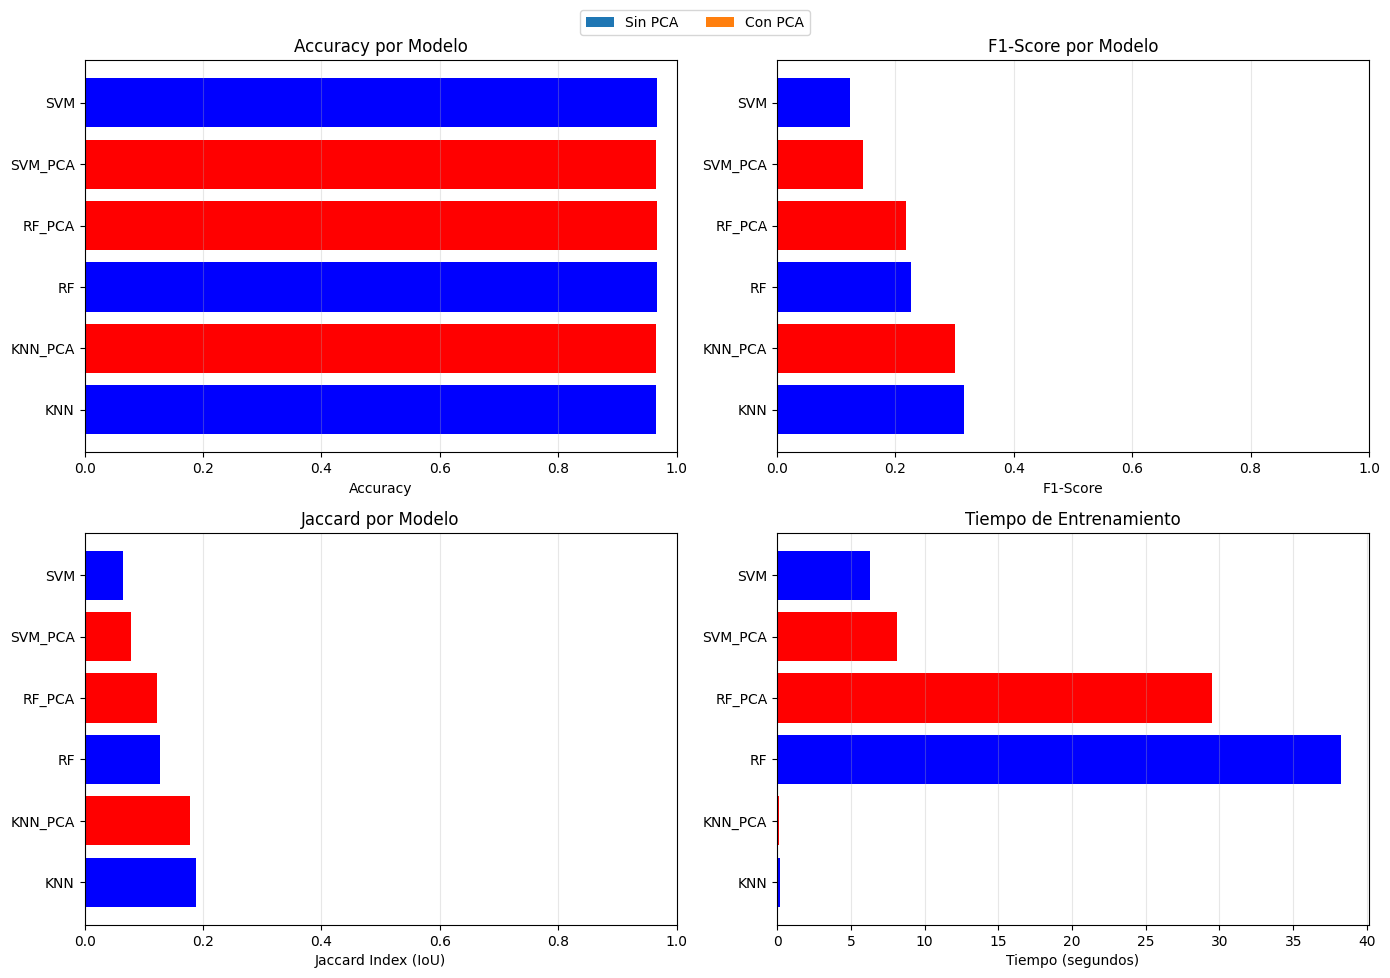

In [32]:
# Gráficos comparativos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Preparar datos para graficar
modelos = df_resultados['Modelo'].values
accuracy = df_resultados['Accuracy'].values
f1 = df_resultados['F1-Score'].values
jaccard = df_resultados['Jaccard (IoU)'].values
tiempo_train = df_resultados['Tiempo Train (s)'].values

colores = ['blue' if 'PCA' not in m else 'red' for m in modelos]

# 1. Accuracy
axes[0, 0].barh(modelos, accuracy, color=colores)
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Accuracy por Modelo')
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. F1-Score
axes[0, 1].barh(modelos, f1, color=colores)
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('F1-Score por Modelo')
axes[0, 1].set_xlim([0, 1])
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Jaccard (IoU)
axes[1, 0].barh(modelos, jaccard, color=colores)
axes[1, 0].set_xlabel('Jaccard Index (IoU)')
axes[1, 0].set_title('Jaccard por Modelo')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Tiempo de entrenamiento
axes[1, 1].barh(modelos, tiempo_train, color=colores)
axes[1, 1].set_xlabel('Tiempo (segundos)')
axes[1, 1].set_title('Tiempo de Entrenamiento')
axes[1, 1].grid(axis='x', alpha=0.3)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', label='Sin PCA'),
    Patch(facecolor='#ff7f0e', label='Con PCA')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, 
           bbox_to_anchor=(0.5, 0.98))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 8. Visualización de Predicciones

Comparamos visualmente las imágenes predichas con el ground truth

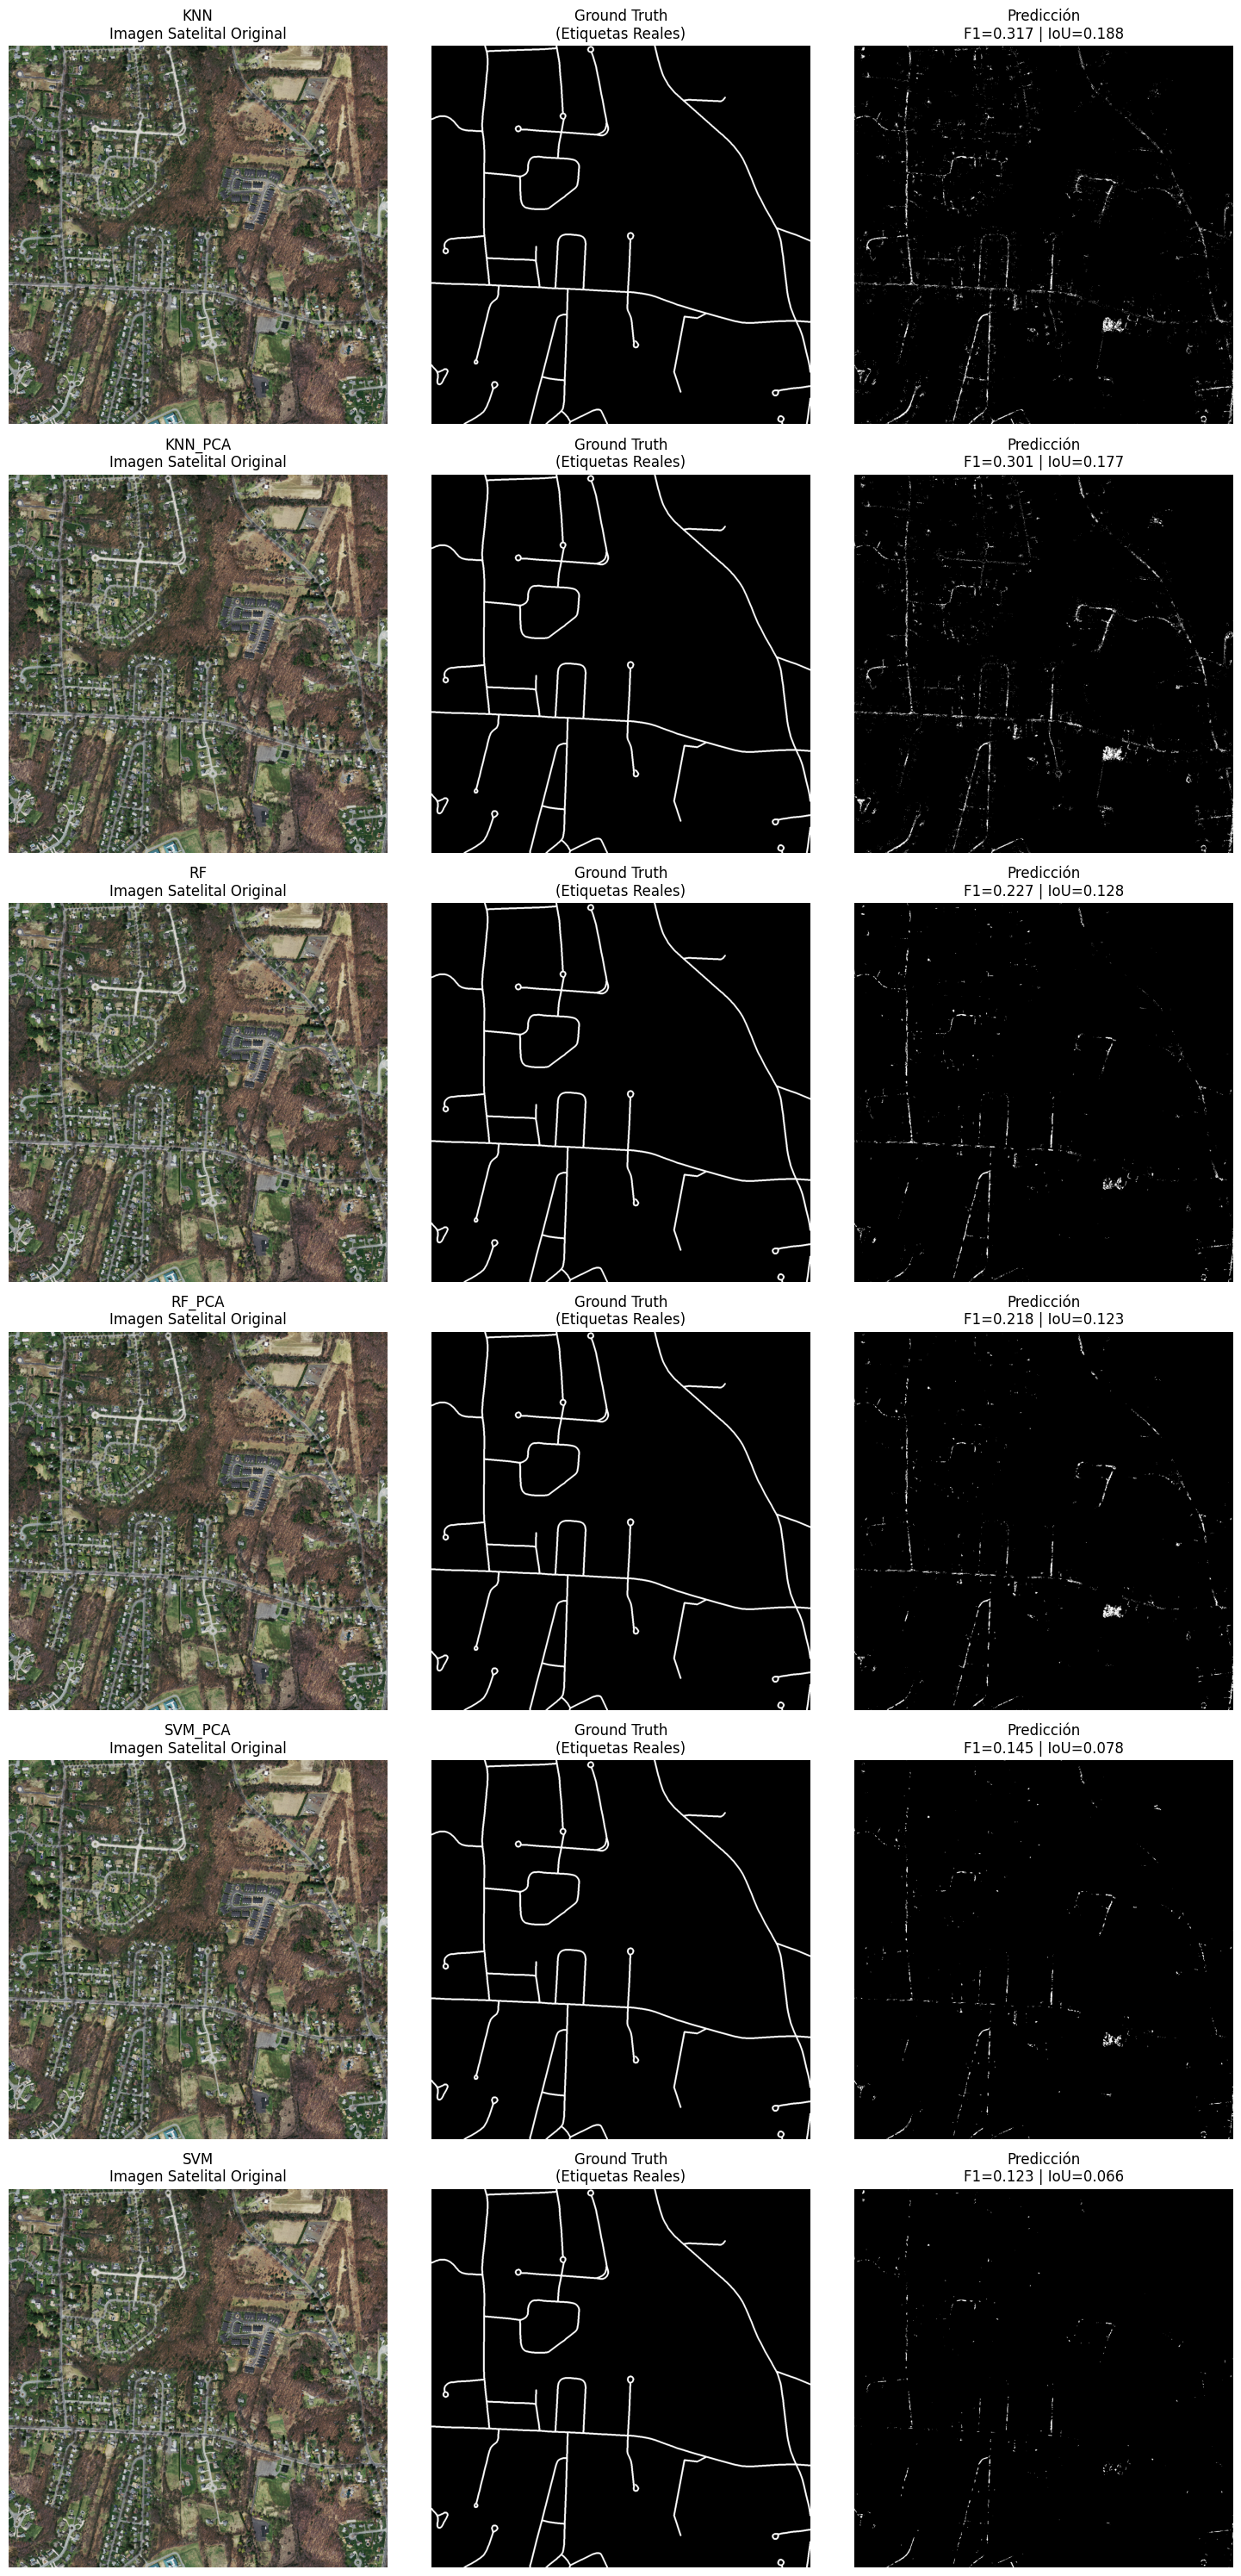

In [ ]:
# Visualizar las 6 mejores predicciones
top6_modelos = df_resultados.head(6)['Modelo'].values

fig, axes = plt.subplots(len(top6_modelos), 3, figsize=(15, 5*len(top6_modelos)))

if len(top6_modelos) == 1:
    axes = axes.reshape(1, -1)

for i, modelo_nombre in enumerate(top6_modelos):
    # Reconstruir imagen predicha
    y_pred = predicciones[modelo_nombre]['y_pred']
    img_pred = y_pred.reshape(H, W)
    
    # Métricas
    f1 = predicciones[modelo_nombre]['f1_score']
    jaccard = predicciones[modelo_nombre]['jaccard']
    
    # Imagen original
    axes[i, 0].imshow(img_test_sat)
    axes[i, 0].set_title(f'{modelo_nombre}\nImagen Satelital Original')
    axes[i, 0].axis('off')
    
    # Ground truth
    axes[i, 1].imshow(img_test_gt, cmap='gray')
    axes[i, 1].set_title('Ground Truth\n(Etiquetas Reales)')
    axes[i, 1].axis('off')
    
    # Predicción
    axes[i, 2].imshow(img_pred, cmap='gray')
    axes[i, 2].set_title(f'Predicción\nF1={f1:.3f} | IoU={jaccard:.3f}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

## 9. Análisis de Resultados y Conclusiones

Interpreta los resultados obtenidos:

In [34]:
# Análisis automático
print("=" * 80)
print("ANÁLISIS DE RESULTADOS")
print("=" * 80)

# Mejor modelo
mejor_modelo = df_resultados.iloc[0]
print(f"\n MEJOR MODELO: {mejor_modelo['Modelo']}")
print(f"   - Accuracy:  {mejor_modelo['Accuracy']:.4f}")
print(f"   - F1-Score:  {mejor_modelo['F1-Score']:.4f}")
print(f"   - Jaccard:   {mejor_modelo['Jaccard (IoU)']:.4f}")

# Efecto del PCA
print("\n EFECTO DE PCA:")
for modelo_base in ['RF', 'SVM', 'KNN']:
    if modelo_base in df_resultados['Modelo'].values:
        modelo_sin_pca = df_resultados[df_resultados['Modelo'] == modelo_base]
        modelo_con_pca = df_resultados[df_resultados['Modelo'] == f'{modelo_base}_PCA']
        
        if not modelo_sin_pca.empty and not modelo_con_pca.empty:
            diff_f1 = modelo_con_pca.iloc[0]['F1-Score'] - modelo_sin_pca.iloc[0]['F1-Score']
            diff_time = modelo_con_pca.iloc[0]['Tiempo Train (s)'] - modelo_sin_pca.iloc[0]['Tiempo Train (s)']
            
            print(f"\n   {modelo_base}:")
            print(f"   - Cambio en F1-Score: {diff_f1:+.4f}")
            print(f"   - Cambio en tiempo:    {diff_time:+.2f}s")
            print(f"   - ¿Mejora?: {'✅ Sí' if diff_f1 > 0 else '❌ No'}")

# Velocidad
print("\n VELOCIDAD:")
mas_rapido = df_resultados.iloc[-1]
print(f"   Más rápido en train: {mas_rapido['Modelo']} ({mas_rapido['Tiempo Train (s)']:.2f}s)")


ANÁLISIS DE RESULTADOS

 MEJOR MODELO: KNN
   - Accuracy:  0.9652
   - F1-Score:  0.3166
   - Jaccard:   0.1881

 EFECTO DE PCA:

   RF:
   - Cambio en F1-Score: -0.0085
   - Cambio en tiempo:    -8.76s
   - ¿Mejora?: ❌ No

   SVM:
   - Cambio en F1-Score: +0.0219
   - Cambio en tiempo:    +1.80s
   - ¿Mejora?: ✅ Sí

   KNN:
   - Cambio en F1-Score: -0.0154
   - Cambio en tiempo:    -0.09s
   - ¿Mejora?: ❌ No

 VELOCIDAD:
   Más rápido en train: SVM (6.32s)
